# Train model ensemble stacking

## 0. Cài đặt & Import

In [ ]:
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

✅ Imports OK


## 1. Load & Audit Data

In [ ]:
train = pd.read_csv('Agri_Data_Train.csv.csv')
test  = pd.read_csv('Agri_Data_Test.csv')

y_test_true = np.expm1(np.log1p(test['Yield']))
test_labels  = test['Yield'].copy()

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')


Train shape: (16000, 51)
Test  shape: (4000, 51)
Test Yield  — min=0.014, max=34.659, mean=3.964


# Biểu đồ check sau khi đã log yield 

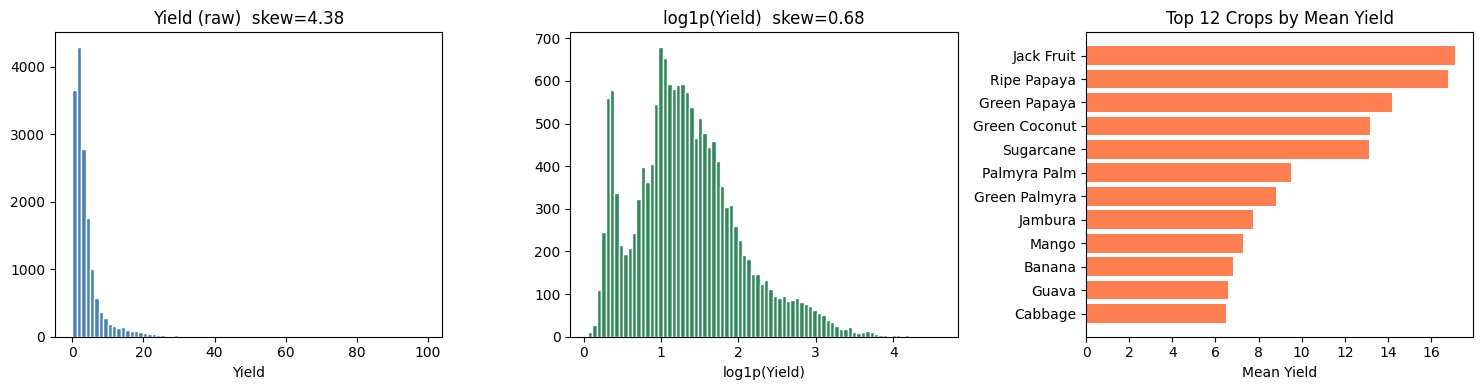

Yield stats:
count    16000.000000
mean         4.013745
std          5.047222
min          0.059688
25%          1.415150
50%          2.546750
75%          4.563600
max         98.990654
Name: Yield, dtype: float64

Missing values: 0


In [ ]:
# --- Yield distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train['Yield'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title(f'Yield (raw)  skew={train["Yield"].skew():.2f}')
axes[0].set_xlabel('Yield')

axes[1].hist(np.log1p(train['Yield']), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p(Yield)  skew={np.log1p(train["Yield"]).skew():.2f}')
axes[1].set_xlabel('log1p(Yield)')

# Top crops by mean yield
top = train.groupby('Crop Name')['Yield'].mean().sort_values(ascending=False).head(12)
axes[2].barh(top.index[::-1], top.values[::-1], color='coral')
axes[2].set_title('Top 12 Crops by Mean Yield')
axes[2].set_xlabel('Mean Yield')

plt.tight_layout()
plt.show()

print(f'Yield stats:\n{train["Yield"].describe()}')

## Target Transform: log1p(Yield)

In [7]:
y = np.log1p(train['Yield'])   # skew=3.53 → mandatory
X = train.drop(columns=['Yield'])

print(f'Target (log1p) — mean: {y.mean():.3f}, std: {y.std():.3f}, skew: {y.skew():.3f}')

Target (log1p) — mean: 1.336, std: 0.687, skew: 0.683


## Transplant → Month Number

In [8]:
MONTH_MAP = {
    'January':1, 'February':2,  'March':3,    'April':4,
    'May':5,     'June':6,       'July':7,     'August':8,
    'September':9,'October':10, 'November':11,'December':12
}

for df in [X, test]:
    df['Transplant'] = df['Transplant'].map(MONTH_MAP).fillna(0).astype(int)

# Verify Boroi
boroi_months = X[train['Crop Name'] == 'Boroi']['Transplant'].unique()
print(f'Boroi transplant months: {sorted(boroi_months)}')

# Raw corr
print(f'corr(Transplant_month, logY) raw: {X["Transplant"].corr(y):.4f}')

Boroi transplant months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
corr(Transplant_month, logY) raw: -0.2035


## KFold Target Encoding

In [ ]:
def kfold_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=20):
    global_mean = target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    enc_train = np.zeros(len(train_df))

    for tr_idx, val_idx in kf.split(train_df):
        fold_data   = train_df[col].iloc[tr_idx]
        fold_target = target.iloc[tr_idx]
        stats = fold_target.groupby(fold_data).agg(['mean', 'count'])
        smooth = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )
        enc_train[val_idx] = (
            train_df[col].iloc[val_idx].map(smooth).fillna(global_mean)
        )

    # Test: use full-train stats
    full_stats = target.groupby(train_df[col]).agg(['mean', 'count'])
    smooth_full = (
        (full_stats['count'] * full_stats['mean'] + smoothing * global_mean)
        / (full_stats['count'] + smoothing)
    )
    enc_test = test_df[col].map(smooth_full).fillna(global_mean).values
    return enc_train, enc_test


for col in ['Crop Name', 'District']:
    X[col + '_TE'], test[col + '_TE'] = kfold_target_encode(X, test, col, y)
    X.drop(columns=[col],   inplace=True)
    test.drop(columns=[col], inplace=True)
    print(f'{col}_TE corr with logY: {pd.Series(X[col+"_TE"]).corr(y):.4f}')

Crop Name_TE corr with logY: 0.8514
District_TE corr with logY: 0.1485


## Encoding các biến category

In [11]:
# Ordinal: Extreme_Heat_Risk
oe = OrdinalEncoder(
    categories=[['Low Risk', 'Medium Risk', 'High Risk']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X['Extreme_Heat_Risk']    = oe.fit_transform(X[['Extreme_Heat_Risk']])
test['Extreme_Heat_Risk'] = oe.transform(test[['Extreme_Heat_Risk']])

# OHE: low cardinality nominals
OHE_COLS = ['Season', 'Dominant_Soil_Texture', 'pH_Suitability', 'Water_Availability_Cat']
X    = pd.get_dummies(X,    columns=OHE_COLS, drop_first=False)
test = pd.get_dummies(test, columns=OHE_COLS, drop_first=False)
test = test.reindex(columns=X.columns, fill_value=0)  # align columns

print(f'Final feature count: {X.shape[1]}')
print(f'X shape: {X.shape} | test shape: {test.shape}')
print(f'Any NaN in X: {X.isnull().sum().sum()}')

Final feature count: 51
X shape: (16000, 51) | test shape: (4000, 51)
Any NaN in X: 0


## 9. Model Training: Ensemble Stacking

In [14]:
# Base learners: Bagging (ET) + Boosting (HGB, XGB, LGBM) diversity
base_models = [
    ('hgb', HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=8,
        max_iter=400,
        random_state=RANDOM_STATE
    )),
    ('xgb', XGBRegressor(
        learning_rate=0.05,
        max_depth=7,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0
    )),
    ('lgbm', LGBMRegressor(
        learning_rate=0.0606,
        num_leaves=121,
        n_estimators=798,
        subsample=0.787,
        colsample_bytree=0.666,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=400,
        max_depth=20,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )),
]

# Meta-learner: Ridge + StandardScaler (vòng 3: OOF preds có different bias/variance)
meta = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=10))
])

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta,
    cv=5,
    n_jobs=-1
)

print('Models defined:')
for name, _ in base_models:
    print(f'  Base: {name}')
print('  Meta: Pipeline(StandardScaler → Ridge(alpha=10))')

Models defined:
  Base: hgb
  Base: xgb
  Base: lgbm
  Base: et
  Meta: Pipeline(StandardScaler → Ridge(alpha=10))


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(np.maximum(y_pred, 0)) - np.log1p(y_true))**2))

def metrics_dict(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    rl   = rmsle(np.array(y_true), np.array(y_pred))
    return dict(R2=r2, MAE=mae, MSE=mse, RMSE=rmse, RMSLE=rl)

def print_row(label, m):
    print(f"  {label:<22}  R²={m['R2']:>7.4f}  MAE={m['MAE']:>7.4f}  "
          f"MSE={m['MSE']:>10.4f}  RMSE={m['RMSE']:>7.4f}  RMSLE={m['RMSLE']:>7.4f}")

kf_eval    = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_true_orig = np.expm1(y)
oof_preds   = {}

print("=" * 85)
print("  OOF 5-Fold Metrics on TRAIN  (honest generalisation estimate)")
print("=" * 85)
for name, model in base_models:
    oof_log  = cross_val_predict(model, X, y, cv=kf_eval)
    oof_orig = np.expm1(oof_log)
    oof_preds[name] = oof_log
    print_row(f"{name.upper()} (OOF)", metrics_dict(y_true_orig, oof_orig))

# Stack OOF
oof_stack_log  = cross_val_predict(stack, X, y, cv=kf_eval)
oof_stack_orig = np.expm1(oof_stack_log)
oof_preds['stack'] = oof_stack_log
print("-" * 85)
print_row("STACK (OOF)", metrics_dict(y_true_orig, oof_stack_orig))
print("=" * 85)


  OOF 5-Fold Metrics on TRAIN  (honest generalisation estimate)
  HGB (OOF)               R²= 0.7294  MAE= 1.0700  MSE=    6.8932  RMSE= 2.6255  RMSLE= 0.2595
  XGB (OOF)               R²= 0.7732  MAE= 0.8937  MSE=    5.7774  RMSE= 2.4036  RMSLE= 0.2158
  LGBM (OOF)              R²= 0.8111  MAE= 0.7976  MSE=    4.8129  RMSE= 2.1938  RMSLE= 0.1940
  ET (OOF)                R²= 0.7894  MAE= 0.8527  MSE=    5.3658  RMSE= 2.3164  RMSLE= 0.2159


OOF Metrics Table:
Model  R² (OOF)  MAE (OOF)  MSE (OOF)  RMSE (OOF)  RMSLE (OOF)
  HGB    0.7294     1.0700     6.8932      2.6255       0.2595
  XGB    0.7732     0.8937     5.7774      2.4036       0.2158
 LGBM    0.8111     0.7976     4.8129      2.1938       0.1940
   ET    0.7894     0.8527     5.3658      2.3164       0.2159
STACK    0.8240     0.7505     4.4829      2.1173       0.1848


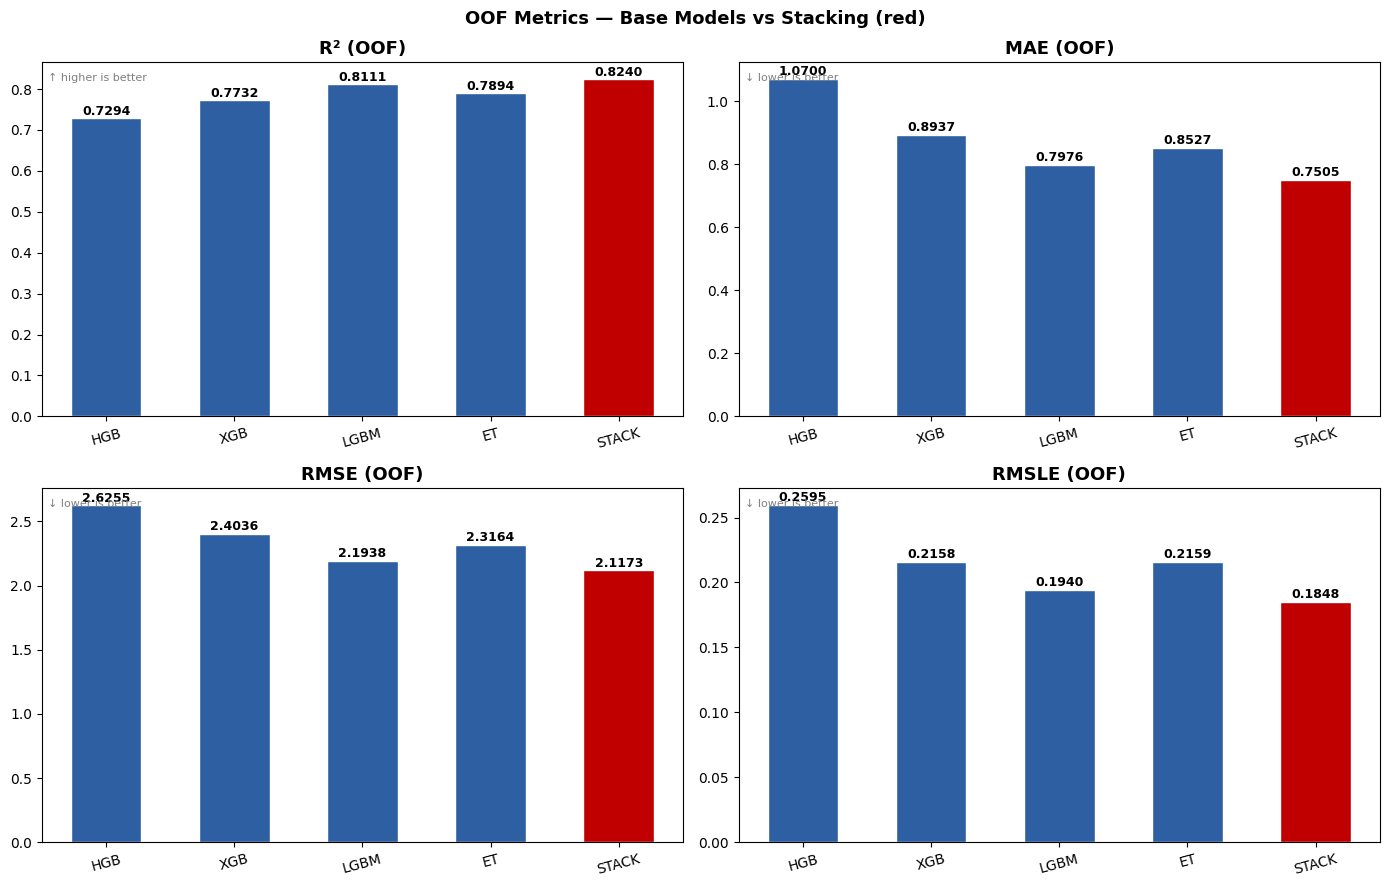

In [ ]:
model_names = [n.upper() for n in list(oof_preds.keys())]
y_true_orig = np.expm1(y)

rows = []
for name, oof_log in oof_preds.items():
    m = metrics_dict(y_true_orig, np.expm1(oof_log))
    rows.append({'Model': name.upper(), **{k: round(v,4) for k,v in m.items()}})

df_oof = pd.DataFrame(rows)
df_oof.columns = ['Model','R² (OOF)','MAE (OOF)','MSE (OOF)','RMSE (OOF)','RMSLE (OOF)']
print("OOF Metrics Table:")
print(df_oof.to_string(index=False))

# 4-panel chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
bar_cols = ['#2E5FA3']*4 + ['#C00000']

for ax, col in zip(axes, ['R² (OOF)','MAE (OOF)','RMSE (OOF)','RMSLE (OOF)']):
    vals = df_oof[col].tolist()
    bars = ax.bar(df_oof['Model'], vals, color=bar_cols, edgecolor='white', width=0.55)
    ax.set_title(col, fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(max(vals)-min(vals))*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    note = '↑ higher is better' if col.startswith('R²') else '↓ lower is better'
    ax.annotate(note, xy=(0.01,0.97), xycoords='axes fraction', fontsize=8, color='gray', va='top')

plt.suptitle('OOF Metrics — Base Models vs Stacking (red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Full Training & Prediction

In [ ]:
print('Fitting full stacking ensemble on all training data...')
stack.fit(X, y)
print('Training complete')


Fitting full stacking ensemble on all training data...
✅ Training complete


In [ ]:
# ── Predictions on test ──────────────────────────────────────────────────────
y_pred_log  = stack.predict(test)
y_pred      = np.expm1(y_pred_log)

# ── All three metric sets ────────────────────────────────────────────────────
y_true_orig      = np.expm1(y)
y_insample_orig  = np.expm1(stack.predict(X))
y_oof_orig       = np.expm1(oof_preds['stack'])
y_test_orig      = test_labels.values          # ground truth from test file

m_train    = metrics_dict(y_true_orig, y_insample_orig)
m_oof      = metrics_dict(y_true_orig, y_oof_orig)
m_test     = metrics_dict(y_test_orig, y_pred)

print("╔════════════════════════════════════════════════════════════════════════╗")
print("║              FINAL METRICS SUMMARY — STACKING ENSEMBLE                ║")
print("╠══════════════╦══════════╦══════════╦═══════════════╦══════════╦════════╣")
print("║  Set         ║   R²     ║   MAE    ║     MSE       ║  RMSE   ║  RMSLE ║")
print("╠══════════════╬══════════╬══════════╬═══════════════╬══════════╬════════╣")
for label, m in [('TRAIN (fit)', m_train), ('TRAIN OOF', m_oof), ('TEST (true)', m_test)]:
    print(f"║  {label:<12}║ {m['R2']:>8.4f} ║ {m['MAE']:>8.4f} ║ {m['MSE']:>13.4f} ║ {m['RMSE']:>8.4f} ║{m['RMSLE']:>7.4f} ║")
print("╚══════════════╩══════════╩══════════╩═══════════════╩══════════╩════════╝")
print()
print("  TRAIN (fit)  = in-sample, model đã thấy data → overfit")
print("  TRAIN OOF    = 5-fold out-of-fold → honest generalisation proxy")
print("  TEST (true)  = predict trên test set có label thật → ground truth")

# Save
pd.DataFrame({'Predicted_Yield': y_pred, 'True_Yield': y_test_orig}).to_csv(
    'predictions_v6.csv', index=False)
print(f"\nSaved predictions_v6.csv  ({len(y_pred)} rows)")


╔════════════════════════════════════════════════════════════════════════╗
║              FINAL METRICS SUMMARY — STACKING ENSEMBLE                ║
╠══════════════╦══════════╦══════════╦═══════════════╦══════════╦════════╣
║  Set         ║   R²     ║   MAE    ║     MSE       ║  RMSE   ║  RMSLE ║
╠══════════════╬══════════╬══════════╬═══════════════╬══════════╬════════╣
║  TRAIN (fit) ║   0.9452 ║   0.3597 ║        1.3966 ║   1.1818 ║ 0.0714 ║
║  TRAIN OOF   ║   0.8240 ║   0.7505 ║        4.4829 ║   2.1173 ║ 0.1848 ║
║  TEST (true) ║   0.8617 ║   0.7628 ║        2.9855 ║   1.7278 ║ 0.2013 ║
╚══════════════╩══════════╩══════════╩═══════════════╩══════════╩════════╝

  TRAIN (fit)  = in-sample, model đã thấy data → overfit
  TRAIN OOF    = 5-fold out-of-fold → honest generalisation proxy
  TEST (true)  = predict trên test set có label thật → ground truth

✅ Saved predictions_v6.csv  (4000 rows)


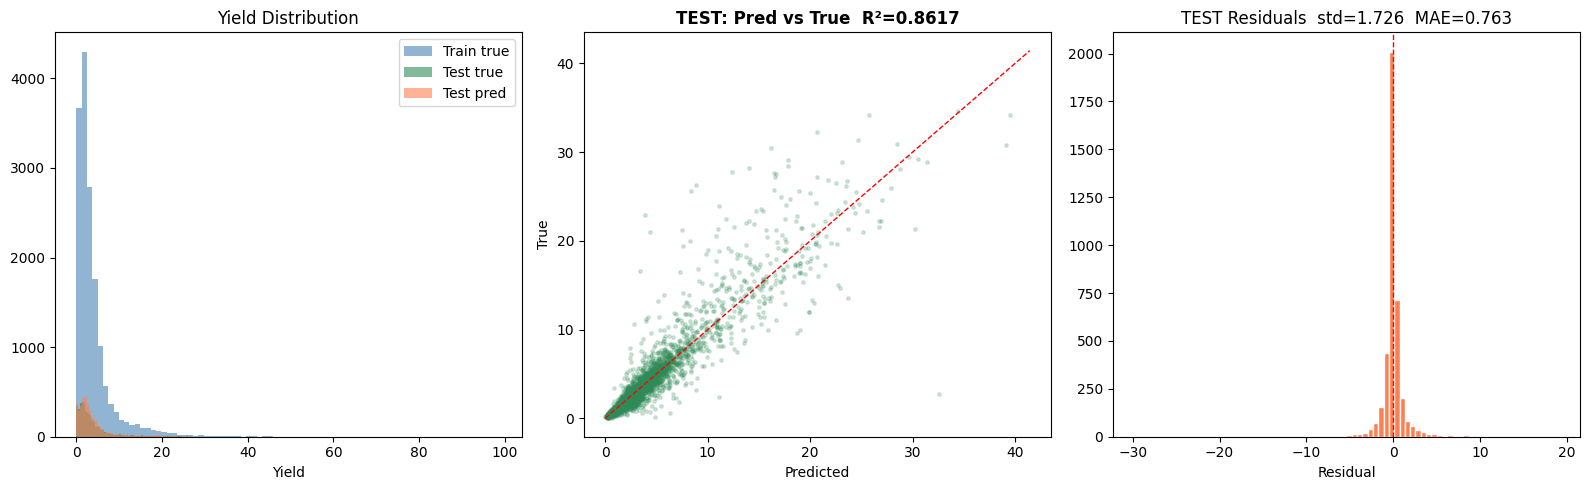

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(train['Yield'],  bins=80, alpha=0.6, label='Train true',  color='steelblue')
axes[0].hist(test_labels,     bins=80, alpha=0.6, label='Test true',   color='seagreen')
axes[0].hist(y_pred,          bins=80, alpha=0.6, label='Test pred',   color='coral')
axes[0].set_xlabel('Yield'); axes[0].legend()
axes[0].set_title('Yield Distribution')

axes[1].scatter(y_pred, test_labels.values, alpha=0.2, s=6, color='seagreen')
lim = max(test_labels.max(), y_pred.max()) * 1.05
axes[1].plot([0,lim],[0,lim],'r--',lw=1)
r2_t = r2_score(test_labels.values, y_pred)
axes[1].set_title(f'TEST: Pred vs True  R²={r2_t:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')


plt.tight_layout()
plt.show()


## 11. Feature Importance Analysis

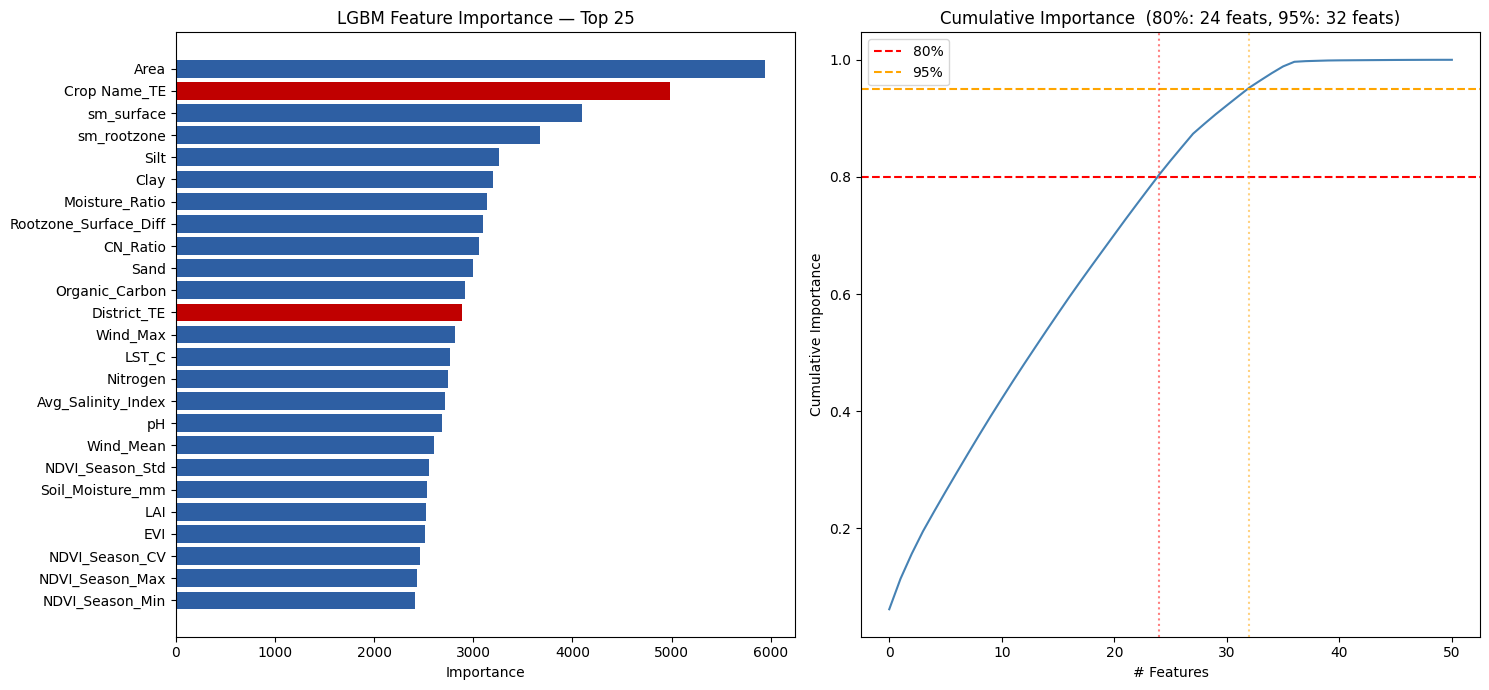


Top 10 features (LGBM):
Area                     5947
Crop Name_TE             4982
sm_surface               4094
sm_rootzone              3677
Silt                     3263
Clay                     3194
Moisture_Ratio           3137
Rootzone_Surface_Diff    3101
CN_Ratio                 3058
Sand                     3000

TE features share of total importance: 8.2%


In [ ]:
# Extract LGBM importance (most reliable for this ensemble)
lgbm_model = stack.named_estimators_['lgbm']
importances = pd.Series(
    lgbm_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top 25
top25 = importances.head(25)
colors = ['#C00000' if '_TE' in n else '#2E5FA3' for n in top25.index]
axes[0].barh(top25.index[::-1], top25.values[::-1], color=colors[::-1])
axes[0].set_title('LGBM Feature Importance — Top 25')
axes[0].set_xlabel('Importance')

# Cumulative importance
cum = importances.cumsum() / importances.sum()
axes[1].plot(range(len(cum)), cum.values, color='steelblue')
axes[1].axhline(0.8, color='red', linestyle='--', label='80%')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95%')
n80  = (cum <= 0.80).sum()
n95  = (cum <= 0.95).sum()
axes[1].axvline(n80,  color='red',    linestyle=':', alpha=0.5)
axes[1].axvline(n95,  color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('# Features'); axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title(f'Cumulative Importance  (80%: {n80} feats, 95%: {n95} feats)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nTop 10 features (LGBM):')
print(importances.head(10).to_string())
print(f'\nTE features share of total importance: '
      f'{importances[importances.index.str.contains("_TE")].sum()/importances.sum():.1%}')